In [22]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from math import e,pi

2.718281828459045

In [13]:
def print_img(img:np.array):
    plt.imshow(img, cmap='gray')
    plt.axis('off') 
    plt.show()

# Definición de funciones de pertenencia

In [65]:


def entrada_baja(x):
    # Triangular
    limite = 128
    return np.where(x < limite, 1 - (x / limite), 0)
    
def entrada_media(x):
    # GAUSS
    sigma = 42
    miu = 128
    return np.exp(-((x - miu)**2.) / (2 * sigma**2.))

def entrada_alta(x):
    # Triangular
    limite1 = 128
    limite2 = 255
    return np.where(x >= limite1, ((x-limite1) / (limite2-limite1)), 0)
    
def salida_baja(y):
    limite = 153
    return np.where(y < limite, 1 - (y / limite), 0)
    
def salida_media(y):

    limite1 = int(0.4*255)
    limite2 = int(0.5*255)
    limite3 = int(0.6*255)

    y_out = np.zeros(len(y))
    idx = np.nonzero(np.logical_and(limite1 < y, y < limite2))[0]
    y_out[idx] = (y[idx] - limite1) / float(limite2 - limite1)

    idx = np.nonzero(np.logical_and(limite2 < y, y < limite3))[0]
    y_out[idx] = (limite3 - y[idx]) / float(limite3 - limite2)

    idx = np.nonzero(y == limite2)
    y_out[idx] = 1

    return y_out

def salida_alta(y):
    # Triangular
    limite1 = 128
    limite2 = 255
    return np.where(y >= limite1, ((y-limite1) / (limite2-limite1)), 0)

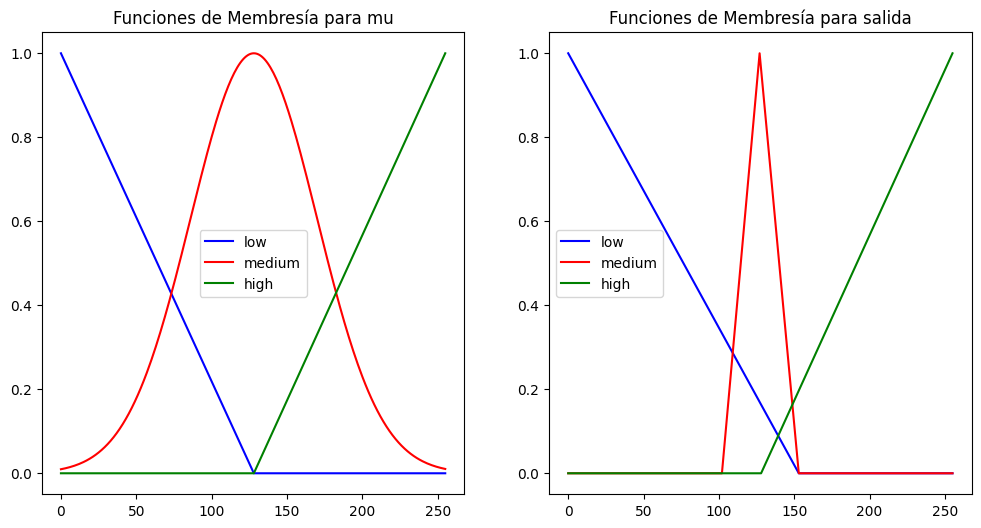

In [84]:
entrada = np.arange(0,256,dtype=int)
salida = entrada.copy()
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
ax[0].plot(entrada,entrada_baja(entrada),'b',label="low")
ax[0].plot(entrada,entrada_media(entrada),'r',label="medium")
ax[0].plot(entrada,entrada_alta(entrada),'g',label="high")
ax[0].set_title('Funciones de Membresía para mu')
ax[0].legend()

ax[1].plot(salida,salida_baja(salida),'b',label="low")
ax[1].plot(salida,salida_media(salida),'r',label="medium")
ax[1].plot(salida,salida_alta(salida),'g',label="high")
ax[1].set_title('Funciones de Membresía para salida')
ax[1].legend()

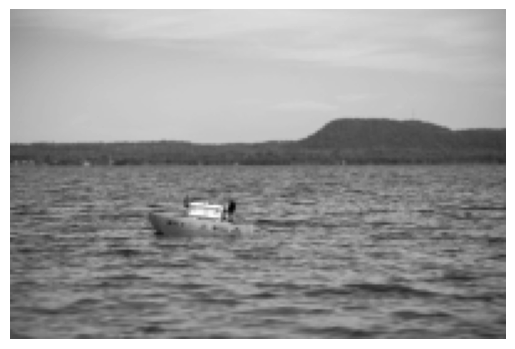

In [71]:
I = cv2.imread("/home/tille/Desktop/Tesis/code/img/barco.jpg",flags=cv2.IMREAD_GRAYSCALE)

I = cv2.resize(I,(200,int(200*m/n)),interpolation=cv2.INTER_AREA)
m,n = I.shape
print_img(I)
o = 3

# A representa la imagen fuzzificada
A = np.zeros((m,n,o))
A[:,:,0] = entrada_baja(I)
A[:,:,1] = entrada_media(I)
A[:,:,2] = entrada_alta(I)



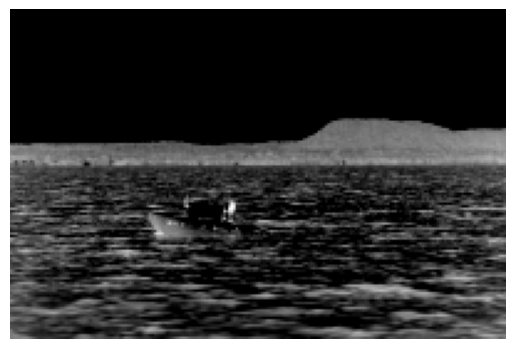

In [83]:
print_img(A[:,:,0])